# MVP — Classificação Multiclasse com o Dry Bean Dataset

**Aluno:** Rafael Medeiros  
**Disciplina:** Engenharia de Software para Sistemas Inteligentes / MVP  
**Objetivo:** desenvolver um modelo de classificação multiclasse com Scikit-learn e integrá-lo posteriormente a uma aplicação full stack simples.

## 1. Contexto do problema

Este notebook apresenta o desenvolvimento de um modelo de machine learning para um problema de **classificação multiclasse** utilizando o **Dry Bean Dataset**.

O objetivo é prever a classe de um grão a partir de atributos geométricos extraídos por visão computacional. O desenvolvimento segue as etapas centrais estudadas na disciplina: carga dos dados, validação inicial, separação entre treino e teste, transformação dos dados, modelagem com algoritmos clássicos, otimização de hiperparâmetros, avaliação comparativa e exportação do modelo final.

Além disso, o modelo resultante será integrado posteriormente a uma aplicação full stack simples, em que o modelo será carregado no back-end e utilizado para realizar predições a partir de novas entradas fornecidas pelo usuário.

## 2. Dataset utilizado

O dataset escolhido foi o **Dry Bean Dataset**, adequado para um problema nativo de classificação.

Ele contém:
- **13.611 instâncias**
- **16 atributos preditores numéricos**
- **7 classes** de saída

A escolha desse dataset foi feita por três motivos principais:

1. ele é compatível com o escopo do MVP, que exige um problema de classificação;
2. possui quantidade de dados suficiente para comparação consistente entre algoritmos clássicos;
3. permite explorar boas práticas de modelagem com dados tabulares numéricos, incluindo padronização, pipelines, validação e comparação de desempenho.

A variável alvo do problema é a coluna `Class`, enquanto os demais atributos representam medições geométricas dos grãos.

In [43]:
!pip install -q openpyxl joblib

In [44]:
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.2

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

## 3. Carga do dataset por URL

Conforme os requisitos do MVP, o dataset é carregado diretamente por **URL**, permitindo a execução do notebook no Google Colab sem necessidade de configuração manual local.

Essa decisão melhora a reprodutibilidade do experimento e facilita a avaliação, já que o notebook pode ser executado do início ao fim em ambiente padronizado.

In [45]:
RAW_URL = "https://raw.githubusercontent.com/rafaelmgsilva/mvp-dry-bean-classification/main/data/Dry_Bean_Dataset.xlsx"

df = pd.read_excel(RAW_URL)

print("Dimensão do dataset:", df.shape)
df.head()

Dimensão do dataset: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291000,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018000,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110000,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884000,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134000,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


## 4. Inspeção inicial e validação dos dados

Antes da modelagem, é importante verificar se o dataset apresenta problemas estruturais que possam comprometer os resultados.

Nesta etapa, serão inspecionados:
- dimensão da base;
- tipos de dados;
- presença de valores ausentes;
- duplicatas;
- distribuição das classes.

Essa etapa é importante porque a qualidade do modelo depende diretamente da qualidade dos dados utilizados no treinamento.

In [46]:
print("Shape:", df.shape)

print("\nTipos de dados:")
display(df.dtypes)

print("\nValores ausentes por coluna:")
display(df.isna().sum())

print("\nQuantidade de duplicatas:", df.duplicated().sum())

print("\nDistribuição das classes:")
display(df["Class"].value_counts())

Shape: (13611, 17)

Tipos de dados:


Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class                  str
dtype: object


Valores ausentes por coluna:


Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


Quantidade de duplicatas: 68

Distribuição das classes:


Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

## 5. Análise exploratória inicial

Antes de iniciar a modelagem, é útil observar a distribuição das classes e algumas estatísticas descritivas dos atributos numéricos.

Como o dataset é composto por variáveis numéricas extraídas por visão computacional, essa etapa ajuda a entender a escala dos dados e a justificar o uso posterior de técnicas como padronização e normalização.

In [47]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,13611.000000,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.000000,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.000000,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860153
MinorAxisLength,13611.000000,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRation,13611.000000,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.000000,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.000000,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.000000,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.000000,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.000000,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


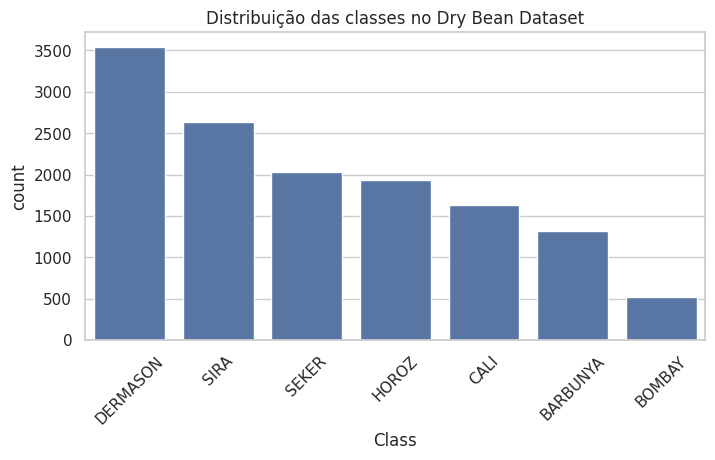

In [48]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="Class", order=df["Class"].value_counts().index)
plt.title("Distribuição das classes no Dry Bean Dataset")
plt.xticks(rotation=45)
plt.show()

## 6. Definição das variáveis de entrada e saída

Neste problema, a variável alvo é `Class`, que representa a classe do grão. As demais colunas serão utilizadas como atributos preditores.

Assim, o problema é tratado como um caso de aprendizado supervisionado para classificação multiclasse.

In [49]:
X = df.drop(columns=["Class"]).copy()
y = df["Class"].copy()

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("\nColunas de entrada:")
display(X.columns)

Shape de X: (13611, 16)
Shape de y: (13611,)

Colunas de entrada:


Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4'],
      dtype='str')

## 7. Separação entre treino e teste

Para avaliar a capacidade de generalização dos modelos, o dataset será particionado em conjuntos de treino e teste utilizando a estratégia de **holdout estratificado**.

A estratificação preserva a proporção das classes em ambos os subconjuntos, o que é importante em problemas multiclasse.

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Treino:")
print("  X_train:", X_train.shape)
print("  y_train:", y_train.shape)

print("\nTeste:")
print("  X_test :", X_test.shape)
print("  y_test :", y_test.shape)

Treino:
  X_train: (10888, 16)
  y_train: (10888,)

Teste:
  X_test : (2723, 16)
  y_test : (2723,)


In [52]:
train_dist = y_train.value_counts(normalize=True).sort_index()
test_dist = y_test.value_counts(normalize=True).sort_index()

distribution_df = pd.DataFrame({
    "train_ratio": train_dist,
    "test_ratio": test_dist,
})

distribution_df

,train_ratio,test_ratio
Class,,
BARBUNYA,0.097079,0.097319
BOMBAY,0.038391,0.038193
CALI,0.119765,0.119721
DERMASON,0.260562,0.260375
HOROZ,0.141624,0.141755
SEKER,0.148880,0.149100
SIRA,0.193699,0.193537


## 8. Baseline de referência

Antes de treinar os algoritmos principais, será criado um baseline com `DummyClassifier`, utilizando a estratégia de prever sempre a classe mais frequente.

O objetivo do baseline é fornecer uma referência mínima de desempenho. Assim, será possível verificar se os modelos treinados realmente aprendem padrões úteis nos dados em vez de reproduzir um comportamento ingênuo.

In [53]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

In [54]:
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)

y_dummy_pred = dummy_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_dummy_pred)
baseline_macro_f1 = f1_score(y_test, y_dummy_pred, average="macro")

baseline_results = pd.DataFrame(
    [
        {
            "model_name": "dummy_baseline",
            "test_accuracy": baseline_accuracy,
            "test_macro_f1": baseline_macro_f1,
        }
    ]
)

baseline_results

,model_name,test_accuracy,test_macro_f1
0,dummy_baseline,0.260375,0.059024


## 9. Interpretação do baseline

O baseline estabelece um ponto de partida simples para comparação. Espera-se que os algoritmos de machine learning superem esse resultado com folga, tanto em acurácia quanto em macro F1-score.

A partir desse ponto, serão treinados os algoritmos exigidos no MVP:
- KNN
- Árvore de Classificação
- Gaussian Naive Bayes
- SVM

## 10. Estratégia de modelagem

Conforme os requisitos do MVP, serão avaliados quatro algoritmos clássicos de classificação:

- KNN
- Árvore de Classificação
- Gaussian Naive Bayes
- SVM

Para os algoritmos sensíveis à escala dos atributos, serão utilizadas transformações de dados com **padronização** e **normalização**, organizadas por meio de **pipelines**.

Além disso, será realizada **otimização de hiperparâmetros** com validação cruzada estratificada, com o objetivo de identificar configurações mais adequadas para cada algoritmo.

## 11. Métricas de avaliação e critério de escolha

As métricas escolhidas para avaliação dos modelos serão:

- **accuracy**
- **macro F1-score**

A acurácia mede a proporção total de classificações corretas. Já o macro F1-score é especialmente importante neste problema multiclasse, porque considera o desempenho médio entre as classes de forma mais equilibrada.

Neste trabalho, o critério principal de escolha do melhor modelo será o **macro F1-score**, com apoio da acurácia.

In [55]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [56]:
candidate_configs = {
    "knn": {
        "pipeline": Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("model", KNeighborsClassifier()),
            ]
        ),
        "param_grid": {
            "scaler": [StandardScaler(), MinMaxScaler()],
            "model__n_neighbors": [3, 5, 7, 9],
            "model__weights": ["uniform", "distance"],
            "model__metric": ["euclidean", "manhattan"],
        },
    },
    "decision_tree": {
        "pipeline": Pipeline(
            steps=[
                ("scaler", "passthrough"),
                ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
            ]
        ),
        "param_grid": {
            "model__criterion": ["gini", "entropy"],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_split": [2, 10],
            "model__min_samples_leaf": [1, 4],
        },
    },
    "gaussian_nb": {
        "pipeline": Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("model", GaussianNB()),
            ]
        ),
        "param_grid": {
            "scaler": [StandardScaler(), MinMaxScaler()],
            "model__var_smoothing": np.logspace(-11, -7, 5),
        },
    },
    "svm": {
        "pipeline": Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("model", SVC(probability=True, random_state=RANDOM_STATE)),
            ]
        ),
        "param_grid": {
            "scaler": [StandardScaler(), MinMaxScaler()],
            "model__C": [0.1, 1, 10],
            "model__kernel": ["linear", "rbf"],
            "model__gamma": ["scale", "auto"],
        },
    },
}

## 12. Justificativa dos pipelines e da busca em grade

A utilização de pipelines ajuda a organizar o fluxo de transformação e treinamento, reduzindo o risco de inconsistência entre treino e teste.

A busca em grade com validação cruzada foi escolhida para permitir uma comparação mais justa entre configurações distintas de cada algoritmo. Em vez de utilizar apenas os parâmetros padrão, a estratégia permite explorar combinações diferentes e selecionar a melhor com base em evidências experimentais.

In [57]:
def train_and_evaluate_model(model_name, config, X_train, y_train, X_test, y_test):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    grid = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["param_grid"],
        scoring={
            "accuracy": "accuracy",
            "macro_f1": "f1_macro",
        },
        refit="macro_f1",
        cv=cv,
        n_jobs=-1,
        verbose=0,
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    result = {
        "model_name": model_name,
        "best_params": grid.best_params_,
        "cv_best_macro_f1": grid.best_score_,
        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "train_macro_f1": f1_score(y_train, y_train_pred, average="macro"),
        "test_macro_f1": f1_score(y_test, y_test_pred, average="macro"),
        "best_estimator": best_model,
        "y_test_pred": y_test_pred,
    }

    return result

## 13. Treinamento e otimização dos modelos

Nesta etapa, cada algoritmo será treinado com seu respectivo pipeline e conjunto de hiperparâmetros. Para cada modelo, será registrada:

- melhor configuração encontrada;
- melhor desempenho em validação cruzada;
- desempenho em treino;
- desempenho em teste.

Essas informações serão usadas para comparar os modelos e analisar sinais de generalização, overfitting e underfitting.

In [58]:
results = []

for model_name, config in candidate_configs.items():
    print(f"Treinando {model_name}...")
    result = train_and_evaluate_model(
        model_name=model_name,
        config=config,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
    )
    results.append(result)

Treinando knn...
Treinando decision_tree...
Treinando gaussian_nb...
Treinando svm...


## 14. Comparação consolidada dos modelos

Após o treinamento, os resultados serão organizados em uma tabela comparativa, permitindo observar o desempenho de cada algoritmo no conjunto de teste e também comparar esse desempenho com os resultados em treino.

Essa comparação é fundamental porque, em machine learning, não existe um algoritmo universalmente superior para todos os problemas. A escolha do melhor modelo deve ser feita com base em evidências experimentais produzidas a partir do problema em questão.

In [59]:
results_df = pd.DataFrame(
    [
        {
            "model_name": r["model_name"],
            "cv_best_macro_f1": r["cv_best_macro_f1"],
            "train_accuracy": r["train_accuracy"],
            "test_accuracy": r["test_accuracy"],
            "train_macro_f1": r["train_macro_f1"],
            "test_macro_f1": r["test_macro_f1"],
            "best_params": r["best_params"],
        }
        for r in results
    ]
).sort_values(by=["test_macro_f1", "test_accuracy"], ascending=False)

results_df

,model_name,cv_best_macro_f1,train_accuracy,test_accuracy,train_macro_f1,test_macro_f1,best_params
3,svm,0.944338,0.939658,0.924348,0.950528,0.936087,"{'model__C': 10, 'model__gamma': 'scale', 'mod..."
0,knn,0.938200,1.000000,0.917371,1.000000,0.930020,"{'model__metric': 'euclidean', 'model__n_neigh..."
1,decision_tree,0.922311,0.950220,0.906721,0.956433,0.920702,"{'model__criterion': 'gini', 'model__max_depth..."
2,gaussian_nb,0.906457,0.897502,0.897907,0.906812,0.909110,"{'model__var_smoothing': 1e-11, 'scaler': Stan..."


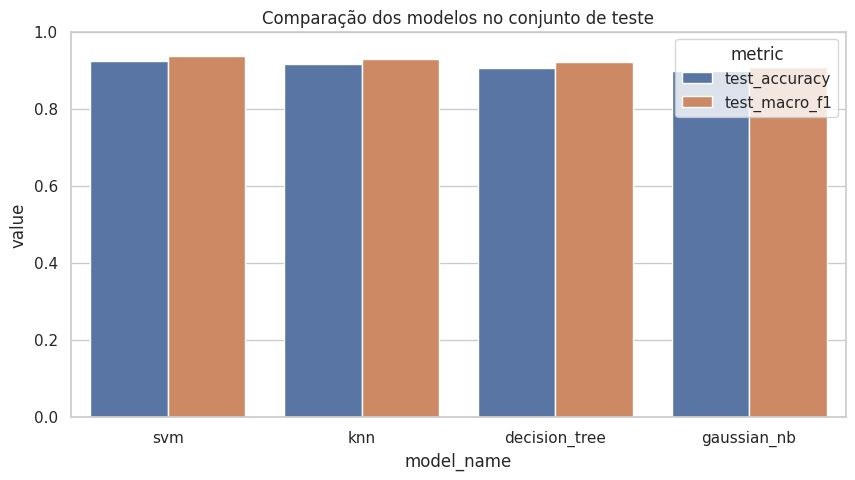

In [60]:
plot_df = results_df[["model_name", "test_accuracy", "test_macro_f1"]].melt(
    id_vars="model_name",
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="model_name", y="value", hue="metric")
plt.ylim(0, 1)
plt.title("Comparação dos modelos no conjunto de teste")
plt.show()

## 15. Interpretação inicial dos resultados

A tabela e o gráfico comparativos permitem observar quais algoritmos apresentaram melhor equilíbrio entre desempenho e generalização.

Nesta etapa, o foco principal é identificar o modelo com melhor macro F1-score no conjunto de teste, além de observar se há diferenças relevantes entre os resultados de treino e teste.

## 16. Escolha do modelo final

Com base nos resultados obtidos, o modelo final será escolhido priorizando o **macro F1-score** no conjunto de teste, com apoio da acurácia.

Essa escolha é adequada porque o problema é multiclasse e o macro F1-score permite uma avaliação mais equilibrada entre as classes.

A partir da comparação realizada, o modelo com melhor desempenho será analisado em mais detalhe.

In [61]:
best_result = max(results, key=lambda r: r["test_macro_f1"])
best_model_name = best_result["model_name"]
best_model = best_result["best_estimator"]

print("Melhor modelo:", best_model_name)
print("Melhores parâmetros:", best_result["best_params"])
print("CV best macro F1:", best_result["cv_best_macro_f1"])
print("Train accuracy:", best_result["train_accuracy"])
print("Test accuracy:", best_result["test_accuracy"])
print("Train macro F1:", best_result["train_macro_f1"])
print("Test macro F1:", best_result["test_macro_f1"])

Melhor modelo: svm
Melhores parâmetros: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf', 'scaler': StandardScaler()}
CV best macro F1: 0.9443376987653709
Train accuracy: 0.9396583394562822
Test accuracy: 0.9243481454278369
Train macro F1: 0.9505281134350455
Test macro F1: 0.9360868835466604


## 17. Análise detalhada do melhor modelo

Após a escolha do melhor modelo, é importante observar seu comportamento com mais detalhe.

Para isso, serão utilizados:
- matriz de confusão;
- relatório de classificação por classe.

Essas visualizações ajudam a identificar quais classes apresentam melhor desempenho e onde ainda existem erros de classificação.

In [62]:
from sklearn.metrics import classification_report, confusion_matrix

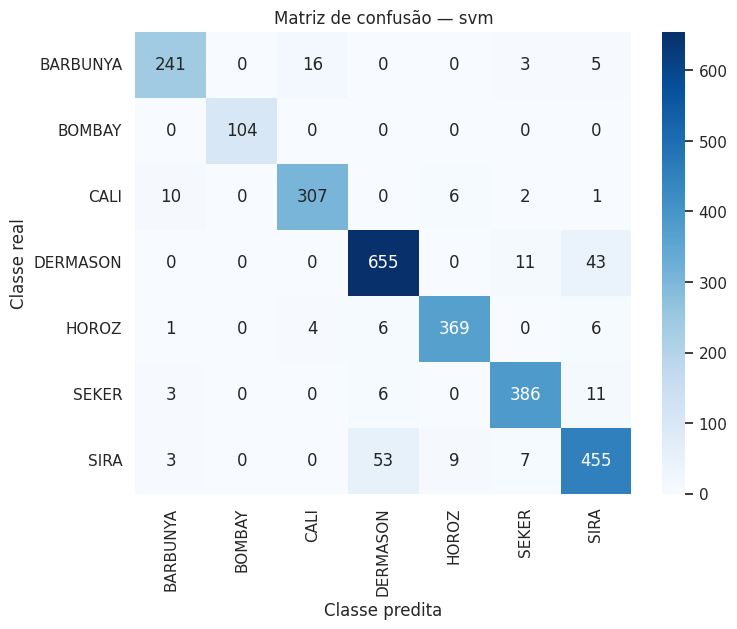

In [63]:
y_best_pred = best_model.predict(X_test)

sorted_labels = sorted(y.unique())

cm = confusion_matrix(y_test, y_best_pred, labels=sorted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted_labels,
    yticklabels=sorted_labels,
)
plt.title(f"Matriz de confusão — {best_model_name}")
plt.xlabel("Classe predita")
plt.ylabel("Classe real")
plt.show()

In [64]:
print(classification_report(y_test, y_best_pred))

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.91      0.92      0.92       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.95      0.95       406
        SIRA       0.87      0.86      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.92      0.92      0.92      2723



## 18. Análise de overfitting e underfitting

Uma etapa importante da avaliação consiste em comparar o desempenho do modelo em treino e teste.

- Quando o desempenho em treino é muito superior ao desempenho em teste, pode haver **overfitting**.
- Quando o desempenho é baixo em ambos, pode haver **underfitting**.

A comparação entre essas métricas ajuda a avaliar a capacidade de generalização do modelo escolhido.

In [65]:
gap_accuracy = best_result["train_accuracy"] - best_result["test_accuracy"]
gap_macro_f1 = best_result["train_macro_f1"] - best_result["test_macro_f1"]

overfit_df = pd.DataFrame(
    [
        {
            "metric": "accuracy",
            "train": best_result["train_accuracy"],
            "test": best_result["test_accuracy"],
            "gap": gap_accuracy,
        },
        {
            "metric": "macro_f1",
            "train": best_result["train_macro_f1"],
            "test": best_result["test_macro_f1"],
            "gap": gap_macro_f1,
        },
    ]
)

overfit_df

,metric,train,test,gap
0,accuracy,0.939658,0.924348,0.015310
1,macro_f1,0.950528,0.936087,0.014441


## 19. Interpretação da generalização

A diferença entre treino e teste permite avaliar se o modelo ficou excessivamente ajustado aos dados de treinamento.

No caso deste experimento, essa comparação será usada como apoio para verificar se o melhor modelo apresenta um comportamento equilibrado, isto é, bom desempenho em treino e também boa capacidade de generalização no conjunto de teste.

## 20. Exportação do modelo e artefatos auxiliares

Após a seleção do melhor modelo, o artefato treinado será exportado para utilização posterior na aplicação full stack.

Além do modelo, também serão salvos arquivos auxiliares com:
- métricas do modelo final;
- nomes das variáveis de entrada;
- intervalos mínimo e máximo observados no treinamento.

Esses metadados são úteis para apoiar validações no back-end e tornar a integração mais robusta.

In [66]:
import json
import joblib

In [67]:
MODEL_PATH = "model.joblib"
METRICS_PATH = "metrics.json"
METADATA_PATH = "metadata.json"

joblib.dump(best_model, MODEL_PATH)


def make_json_serializable(value):
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    if isinstance(value, dict):
        return {k: make_json_serializable(v) for k, v in value.items()}
    if isinstance(value, list):
        return [make_json_serializable(v) for v in value]
    if hasattr(value, "__class__") and not isinstance(value, (str, int, float, bool, type(None))):
        return value.__class__.__name__
    return value


metrics = {
    "best_model_name": best_model_name,
    "test_accuracy": float(best_result["test_accuracy"]),
    "test_macro_f1": float(best_result["test_macro_f1"]),
    "best_params": make_json_serializable(best_result["best_params"]),
}

metadata = {
    "feature_columns": list(X.columns),
    "feature_ranges": {
        column: {
            "min": float(X[column].min()),
            "max": float(X[column].max()),
        }
        for column in X.columns
    },
}

with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4)

with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print("Arquivos exportados com sucesso:")
print("-", MODEL_PATH)
print("-", METRICS_PATH)
print("-", METADATA_PATH)

Arquivos exportados com sucesso:
- model.joblib
- metrics.json
- metadata.json


## 21. Reflexão sobre segurança e privacidade

Embora o Dry Bean Dataset não contenha dados pessoais, ainda assim é possível aplicar princípios de desenvolvimento de software seguro ao problema.

Neste projeto, algumas práticas relevantes incluem:
- validação rigorosa das entradas recebidas pela aplicação;
- verificação de valores fora da faixa observada no treinamento;
- proteção da integridade dos artefatos exportados;
- testes automatizados para evitar regressão funcional e de desempenho;
- uso de comunicação segura em ambiente real.

Em um cenário real com dados sensíveis, também seria importante considerar técnicas de anonimização ou pseudoanonimização, além da adoção de princípios como security by design e privacy by design. O enunciado do MVP pede essa reflexão explicitamente. :contentReference[oaicite:0]{index=0}

## 22. Principais achados e pontos de atenção

Os experimentos mostraram que foi possível treinar e comparar diferentes algoritmos clássicos de classificação no Dry Bean Dataset com desempenho satisfatório.

Os principais achados deste trabalho incluem:
- desempenho superior dos modelos mais fortes no conjunto de teste;
- importância do uso de transformação de dados para algoritmos sensíveis à escala;
- utilidade dos pipelines para organizar o fluxo de modelagem;
- ganho de qualidade com a otimização de hiperparâmetros por validação cruzada.

Como ponto de atenção, é importante lembrar que entradas muito fora da faixa observada no treinamento podem reduzir a confiabilidade das predições, mesmo quando o modelo ainda consegue produzir uma saída.

## 23. Conclusão

Este notebook apresentou o desenvolvimento completo de um modelo de classificação multiclasse com o Dry Bean Dataset, seguindo etapas centrais da engenharia de sistemas inteligentes.

O processo contemplou:
- carga do dataset por URL;
- validação inicial dos dados;
- análise exploratória;
- separação entre treino e teste;
- modelagem com KNN, Árvore de Classificação, Gaussian Naive Bayes e SVM;
- otimização de hiperparâmetros com validação cruzada;
- comparação dos modelos;
- análise do melhor modelo;
- exportação do artefato final.

Os resultados obtidos indicam que foi possível construir um classificador com bom desempenho, apto a ser integrado a uma aplicação full stack simples para predição de novas entradas.

Como evolução futura, seria interessante aprofundar a explicabilidade do modelo, investigar calibração de probabilidades, testar modelos ensemble e monitorar comportamento em produção.